# Feature Adoption Causal Impact

Product question: did one-click checkout increase spend, or did high-value customers simply adopt it first?
Simulated feature-adoption table with pre-period spend, account age, adoption status, and post-period spend.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
%matplotlib inline


In [ ]:
df_users = pd.read_csv('../data/user_adoption_data.csv')
df_users.head(10)


,user_id,user_age_days,pre_spend,adopted_feature,post_spend
0,U00000,481,49.42,0,46.28
1,U00001,370,68.92,0,72.38
2,U00002,391,81.89,1,101.47
3,U00003,163,76.69,1,87.06
4,U00004,166,22.46,0,23.56
5,U00005,390,40.33,0,39.28
6,U00006,78,29.01,0,24.77
7,U00007,115,58.75,1,71.61
8,U00008,145,13.11,0,5.00
9,U00009,488,20.70,1,30.24


### naive comparison: selection bias
check spend difference between those who adopted and those who didn't.

In [ ]:
naive_comp = df_users.groupby('adopted_feature')[['pre_spend', 'post_spend']].mean()
naive_comp['spend_growth'] = naive_comp['post_spend'] - naive_comp['pre_spend']
print(naive_comp)


                 pre_spend  post_spend  spend_growth
adopted_feature                                     
0                33.870319   33.583965     -0.286355
1                62.794386   75.194258     12.399872


adopters have much higher post_spend, but their pre_spend was already far higher.
if we claim the feature increased spend by the raw difference, the estimate would overstate the feature impact.

### propensity score estimation
estimate the probability of adoption given pre-treatment variables (user_age_days and pre_spend).

In [ ]:
import statsmodels.api as sm
X_covs = df_users[['pre_spend', 'user_age_days']]
X_covs_const = sm.add_constant(X_covs)
y_adopt = df_users['adopted_feature']

prop_model = sm.Logit(y_adopt, X_covs_const).fit()
df_users['propensity_score'] = prop_model.predict(X_covs_const)
df_users.head()


Optimization terminated successfully.
         Current function value: 0.591532
         Iterations 6


,user_id,user_age_days,pre_spend,adopted_feature,post_spend,propensity_score
0,U00000,481,49.42,0,46.28,0.624617
1,U00001,370,68.92,0,72.38,0.711613
2,U00002,391,81.89,1,101.47,0.790542
3,U00003,163,76.69,1,87.06,0.685824
4,U00004,166,22.46,0,23.56,0.301488


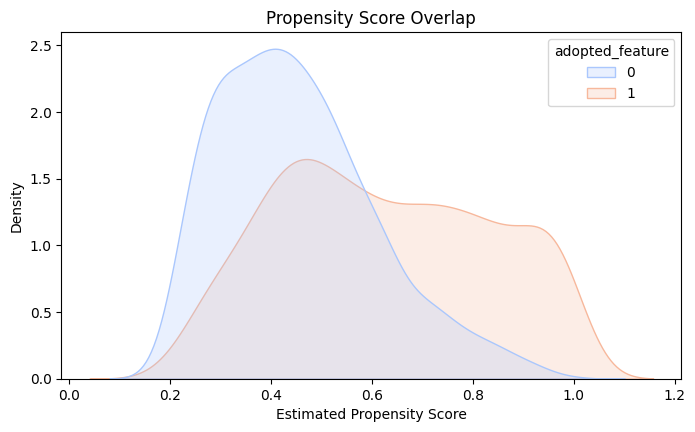

In [ ]:
plt.figure(figsize=(8, 4.5))
sns.kdeplot(data=df_users, x='propensity_score', hue='adopted_feature', fill=True, common_norm=False, palette='coolwarm')
plt.title('Propensity Score Overlap')
plt.xlabel('Estimated Propensity Score')
plt.show()


### nearest-neighbor matching
Each adopter is paired with the closest non-adopter by propensity score.

In [ ]:
treated = df_users[df_users['adopted_feature'] == 1].copy()
control = df_users[df_users['adopted_feature'] == 0].copy()

matched_control_indices = []
control_pool = control.copy()

for idx, row in treated.iterrows():
    diffs = abs(control_pool['propensity_score'] - row['propensity_score'])
    best_match_idx = diffs.idxmin()
    matched_control_indices.append(best_match_idx)

matched_control = control.loc[matched_control_indices]
print(f"matched sample size: {len(treated)} pairs")


matched sample size: 1092 pairs


### checking balance
compare the pre-treatment covariates before and after matching.

In [ ]:
print("=== UNMATCHED COHORT MEANS ===")
print(df_users.groupby('adopted_feature')[['pre_spend', 'user_age_days']].mean())

print("\n=== MATCHED COHORT MEANS ===")
print("Treated:")
print(treated[['pre_spend', 'user_age_days']].mean())
print("Matched Control:")
print(matched_control[['pre_spend', 'user_age_days']].mean())


=== UNMATCHED COHORT MEANS ===
                 pre_spend  user_age_days
adopted_feature                          
0                33.870319     343.415198
1                62.794386     400.356227

=== MATCHED COHORT MEANS ===
Treated:
pre_spend         62.794386
user_age_days    400.356227
dtype: float64
Matched Control:
pre_spend         62.579121
user_age_days    393.216117
dtype: float64


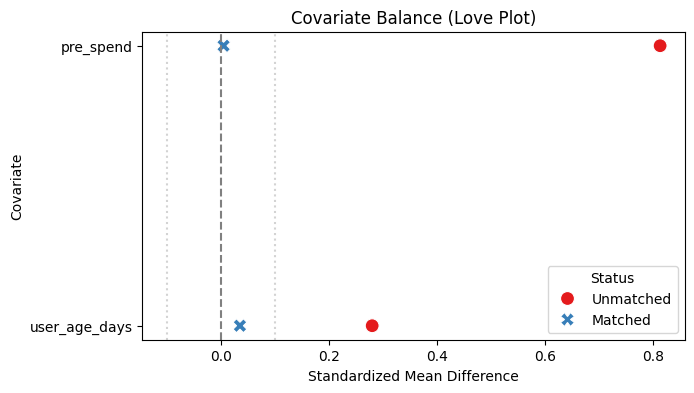

In [ ]:
def calc_smd(df_t, df_c, cols):
    smds = {}
    for col in cols:
        mean_t = df_t[col].mean()
        mean_c = df_c[col].mean()
        var_t = df_t[col].var()
        var_c = df_c[col].var()
        pooled_sd = np.sqrt((var_t + var_c) / 2)
        smds[col] = (mean_t - mean_c) / pooled_sd
    return smds

covariates = ['pre_spend', 'user_age_days']
smd_unmatched = calc_smd(df_users[df_users['adopted_feature']==1], df_users[df_users['adopted_feature']==0], covariates)
smd_matched = calc_smd(treated, matched_control, covariates)

df_smd = pd.DataFrame({
    'Covariate': covariates * 2,
    'SMD': list(smd_unmatched.values()) + list(smd_matched.values()),
    'Status': ['Unmatched'] * len(covariates) + ['Matched'] * len(covariates)
})

plt.figure(figsize=(7, 4))
sns.scatterplot(data=df_smd, x='SMD', y='Covariate', hue='Status', style='Status', s=100, palette='Set1')
plt.axvline(0, color='gray', linestyle='--')
plt.axvline(0.1, color='lightgray', linestyle=':')
plt.axvline(-0.1, color='lightgray', linestyle=':')
plt.title('Covariate Balance (Love Plot)')
plt.xlabel('Standardized Mean Difference')
plt.show()


the covariates are now almost identical. the bias is mitigated.

### calculating Average Treatment Effect on the Treated (ATT)

In [ ]:
treated_diff = treated['post_spend'].values - treated['pre_spend'].values
control_diff = matched_control['post_spend'].values - matched_control['pre_spend'].values

att_val = treated_diff.mean() - control_diff.mean()
t_stat, p_val = stats.ttest_rel(treated_diff, control_diff)
print(f"Estimated ATT (incremental spend): ${att_val:.2f}")
print(f"Matched Rel T-test p-value:        {p_val:.6f}")


Estimated ATT (incremental spend): $12.24
Matched Rel T-test p-value:        0.000000


The matched estimate is close to the true incremental effect (~$12), while the naive comparison would have overstated impact by more than 3x.